# Découverte de Pattern Functional Dependencies (PFDs) assistée par LLM

## Contexte

Une **Pattern Functional Dependency (PFD)** est une généralisation des dépendances 
fonctionnelles classiques : au lieu de travailler sur les valeurs brutes, elle s'applique 
sur des *patterns* extraits de ces valeurs.

**Exemple :** `prefix(ZIP, 3) → CITY`  
Les 3 premiers chiffres d'un code postal déterminent la ville.

L'enjeu de la découverte de PFDs est double :
- **Profiling de données** : comprendre la structure implicite d'un dataset
- **Qualité des données** : détecter des incohérences ou anomalies

L'approche classique (force brute) teste toutes les combinaisons possibles 
(colonnes × transformations), ce qui devient coûteux sur des datasets larges. 
Ce projet explore l'apport des LLMs pour guider et accélérer cette découverte.

## Transformations disponibles

Les valeurs de chaque colonne peuvent être transformées avant d'évaluer une dépendance :

| Transformation | Description | Exemple |
|---|---|---|
| `raw` | Valeur brute | `"New York"` |
| `prefix_n` | n premiers caractères | `prefix_3("90210")` → `"902"` |
| `suffix_n` | n derniers caractères | `suffix_2("gmail.com")` → `"om"` |
| `first_token` | Premier mot | `"John Smith"` → `"John"` |
| `last_token` | Dernier mot | `"John Smith"` → `"Smith"` |
| `domain` | Domaine d'un email | `"u@gmail.com"` → `"gmail.com"` |
| `uppercase` / `lowercase` | Normalisation de casse | `"NY"` → `"ny"` |

## Trois workflows comparés

### Workflow classique
Force brute : toutes les paires (colonne × transformation) sont testées.  
Exhaustif mais lent — plusieurs centaines de candidats par dataset.

### Workflow agentique v1
Le LLM analyse les colonnes et suggère les transformations pertinentes *par colonne* 
avant la découverte. L'algorithme n'explore que ce sous-ensemble.  
→ Réduction du nombre de candidats testés (~50-70%)

### Workflow agentique v2 — Guided Search
Le LLM propose directement des **paires complètes** `(colonne source, transformation, colonne cible)`.  
L'algorithme valide uniquement ces paires — aucune exploration.  
→ 8 à 15 candidats testés au lieu de plusieurs centaines

## Providers LLM et modèles

| Provider | Modèle | Taille |
|---|---|---|
| Groq | `llama-3.3-70b-versatile` | 70B |
| HuggingFace | `Qwen2.5-7B-Instruct` | 7B |
| Mistral | `mistral-large-latest` | ~123B |

## Métriques d'évaluation

- **nb_pfds** : nombre de PFDs découvertes
- **candidates_tested** : nombre de paires évaluées algorithmiquement
- **validation_rate** : `nb_pfds / candidates_tested` — proportion de paires proposées qui tiennent statistiquement (pertinent surtout pour v2)
- **mean_confidence** : confiance moyenne des PFDs découvertes
- **mean_support** : support moyen (nombre de lignes couvertes)
- **execution_time** : temps d'exécution total en secondes

Une PFD est retenue si `confidence ≥ 0.85` et `support ≥ 10`.

Le code suivant permet d'afficher toutes les pfd trouvées par les différents algorithmes et modèles pour le dataset indiqué dans la variable DATASET.

In [63]:
import json
import os
import pandas as pd
from IPython.display import display

from pathlib import Path

DATASET     = "t3.csv"
RESULTS_DIR = Path().resolve().parent / "results"
DATA_DIR    = Path().resolve().parent / "data" / "pfd_validation"

N_TOTAL = len(pd.read_csv(DATA_DIR / DATASET))
print(f"Dataset : {DATASET} — {N_TOTAL} lignes au total")
# ───────────────────────────────────────────────────────────────

def load_pfds(dataset, workflow, results_dir):
    results = {}
    prefix = f"{dataset}_{workflow}_"

    for fname in sorted(os.listdir(results_dir)):
        if not fname.startswith(prefix) or not fname.endswith(".json"):
            continue
        provider = fname[len(prefix):-len(".json")]
        with open(os.path.join(results_dir, fname), encoding="utf-8") as f:
            data = json.load(f)

        runs = data.get("runs", [])
        n_runs = len(runs)

        # Compter dans combien de runs chaque PFD apparaît
        counts = {}
        values = {}
        for run in runs:
            for pfd in run.get("discovered_pfds", []):
                key = (pfd["lhs"], pfd["rhs"])
                counts[key] = counts.get(key, 0) + 1
                values[key] = pfd  # on garde les métriques du dernier run

        pfds = []
        for key, pfd in values.items():
            pfds.append({**pfd, "found_in_runs": f"{counts[key]}/{n_runs}"})

        results[provider] = {
            "pfds":    pfds,
            "nb_runs": n_runs,
            "params":  data.get("params", {}),
        }
    return results


def afficher_pfds(pfds, titre):
    print(f"\n{'='*60}")
    print(f"  {titre}")
    print(f"{'='*60}")
    if not pfds:
        print("  Aucune PFD trouvée.")
        return
    cols = ["lhs", "rhs", "support", "confidence", "found_in_runs"]
    df = (pd.DataFrame(pfds)[cols]
            .sort_values("confidence", ascending=False)
            .reset_index(drop=True))
    df["coverage"] = (df["support"] / N_TOTAL).round(4)
    display(df)

Dataset : t3.csv — 1077 lignes au total


In [64]:
classique = load_pfds(DATASET, "classical", RESULTS_DIR)

if classique:
    data = classique.get("none", {})
    afficher_pfds(data.get("pfds", []), f"Classique — {DATASET}")
else:
    print(f"Aucun résultat classique trouvé pour {DATASET}")


  Classique — t3.csv


,lhs,rhs,support,confidence,found_in_runs,coverage
0,Location__suffix_4,State,1076,1.0000,3/3,0.9991
1,Location__first_token,State,1076,1.0000,3/3,0.9991
2,Location__last_token,State,1076,1.0000,3/3,0.9991
3,Location__suffix_2,State,1076,1.0000,3/3,0.9991
4,Location__suffix_3,State,1076,1.0000,3/3,0.9991
...,...,...,...,...,...,...
285,Account Name__prefix_5,Zip,1076,0.8717,3/3,0.9991
286,Licensee Name__prefix_3,Channel Type,1075,0.8670,3/3,0.9981
287,Account Name__first_token,City,1076,0.8634,3/3,0.9991
288,Location__first_token,Street,1076,0.8606,3/3,0.9991


In [65]:
agent_v1 = load_pfds(DATASET, "agent_v1", RESULTS_DIR)

if agent_v1:
    for provider, data in agent_v1.items():
        titre = f"Agent v1 — {provider.upper()}  ({data['nb_runs']} run(s))"
        afficher_pfds(data["pfds"], titre)
else:
    print(f"Aucun résultat agent_v1 trouvé pour {DATASET}")


  Agent v1 — GROQ  (3 run(s))


,lhs,rhs,support,confidence,found_in_runs,coverage
0,Licensee Name__first_token,State,1076,1.0000,3/3,0.9991
1,Licensee Name__last_token,State,1076,1.0000,3/3,0.9991
2,Licensee Name__raw,State,1076,1.0000,3/3,0.9991
3,Zip__raw,State,1076,1.0000,3/3,0.9991
4,City__raw,State,1076,1.0000,3/3,0.9991
...,...,...,...,...,...,...
71,Location__last_token,Account Name,1076,0.9284,2/3,0.9991
72,Licensee Name__last_token,Channel Type,1075,0.9126,3/3,0.9981
73,Account Name__first_token,City,1076,0.8634,3/3,0.9991
74,Location__first_token,Street,1076,0.8606,2/3,0.9991



  Agent v1 — HUGGINGFACE  (3 run(s))


,lhs,rhs,support,confidence,found_in_runs,coverage
0,Licensee Name__raw,State,1076,1.0000,3/3,0.9991
1,Zip__prefix_3,State,1076,1.0000,3/3,0.9991
2,City__raw,State,1076,1.0000,3/3,0.9991
3,Street__raw,Zip,1076,1.0000,3/3,0.9991
4,Street__raw,City,1076,1.0000,3/3,0.9991
5,Street__raw,State,1076,1.0000,3/3,0.9991
6,Licensee Name__last_token,State,1076,1.0000,3/3,0.9991
7,Licensee Name__first_token,State,1076,1.0000,3/3,0.9991
8,City__uppercase,State,1076,1.0000,3/3,0.9991
9,Account Name__first_token,State,1076,1.0000,3/3,0.9991



  Agent v1 — MISTRAL  (3 run(s))


,lhs,rhs,support,confidence,found_in_runs,coverage
0,Licensee Name__raw,State,1076,1.0000,3/3,0.9991
1,Licensee Name__first_token,State,1076,1.0000,3/3,0.9991
2,Licensee Name__last_token,State,1076,1.0000,3/3,0.9991
3,Street__raw,State,1076,1.0000,3/3,0.9991
4,Street__raw,City,1076,1.0000,3/3,0.9991
...,...,...,...,...,...,...
102,Location__first_token,Zip,1076,0.9349,3/3,0.9991
103,Licensee Name__last_token,Channel Type,1075,0.9126,3/3,0.9981
104,Account Name__first_token,City,1076,0.8634,3/3,0.9991
105,Location__first_token,Street,1076,0.8606,3/3,0.9991


In [66]:
agent_v2 = load_pfds(DATASET, "agent_v2", RESULTS_DIR)

if agent_v2:
    for provider, data in agent_v2.items():
        titre = f"Agent v2 — {provider.upper()}  ({data['nb_runs']} run(s))"
        afficher_pfds(data["pfds"], titre)
else:
    print(f"Aucun résultat agent_v2 trouvé pour {DATASET}")


  Agent v2 — GROQ  (3 run(s))


,lhs,rhs,support,confidence,found_in_runs,coverage
0,Location__suffix_3,State,1076,1.0000,1/3,0.9991
1,Licensee Number__first_token,Account Name,1076,0.9991,1/3,0.9991
2,Street__raw,Location,1076,0.9981,1/3,0.9991
3,Location__prefix_5,Street,1076,0.8894,1/3,0.9991
4,Street__prefix_5,Location,1076,0.8875,1/3,0.9991
5,Street__first_token,Location,1076,0.8587,1/3,0.9991



  Agent v2 — HUGGINGFACE  (3 run(s))


,lhs,rhs,support,confidence,found_in_runs,coverage
0,City__uppercase,State,1076,1.0000,3/3,0.9991
1,City__last_token,State,1076,1.0000,1/3,0.9991
2,City__first_token,State,1076,1.0000,2/3,0.9991
3,Street__uppercase,Location,1076,0.9981,1/3,0.9991
4,Licensee Name__uppercase,Account Name,1076,0.9963,3/3,0.9991
5,Licensee Name__uppercase,Licensee Number,1076,0.9954,1/3,0.9991
6,Licensee Name__first_token,Channel Type,1075,0.9451,4/3,0.9981



  Agent v2 — MISTRAL  (3 run(s))


,lhs,rhs,support,confidence,found_in_runs,coverage
0,Location__suffix_2,State,1076,1.0000,1/3,0.9991
1,Street__raw,Zip,1076,1.0000,1/3,0.9991
2,City__raw,State,1076,1.0000,2/3,0.9991
3,Street__raw,Location,1076,0.9981,2/3,0.9991
4,Location__last_token,Zip,1076,0.9981,2/3,0.9991
5,Licensee Name__uppercase,Account Name,1076,0.9963,2/3,0.9991
6,Licensee Name__lowercase,Account Name,1076,0.9963,1/3,0.9991
7,Location__last_token,City,1076,0.9935,1/3,0.9991
8,Account Name__lowercase,Licensee Name,1076,0.9851,1/3,0.9991
9,Account Name__uppercase,Licensee Name,1076,0.9851,1/3,0.9991


## Data Profiling — Analyse par colonne

Exploration détaillée d'une colonne du dataset sélectionné (`DATASET`).  
Modifier la variable `COLUMN` dans la cellule suivante pour changer de colonne.

Pour chaque colonne, le profil affiche :
- **Infos générales** : type, nombre de nulls, nombre de valeurs uniques
- **Colonnes numériques** : min, max, moyenne, quartiles, histogramme de distribution
- **Colonnes textuelles** : distribution des longueurs, détection de patterns (email, date, téléphone…)
- **Top 10 valeurs** les plus fréquentes avec pourcentages

In [30]:
import sys
!{sys.executable} -m pip install matplotlib

  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------------------------------------- -- 7.6/8.2 MB 39.4 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 34.3 MB/s eta 0:00:00
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 32.0 MB/s eta 0:00:00
Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl (73 kB)
Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl (7.1 MB)



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [67]:
import matplotlib.pyplot as plt

# Chargement du dataframe complet
df = pd.read_csv(DATA_DIR / DATASET)
print(f"Dataset : {DATASET}  —  {len(df)} lignes, {len(df.columns)} colonnes")
print(f"Colonnes disponibles : {list(df.columns)}")


def _section(title):
    print(f"\n  {'─'*40}")
    print(f"  {title}")


def profile_column(df, col):
    if col not in df.columns:
        print(f"Colonne '{col}' introuvable. Disponibles : {list(df.columns)}")
        return

    s = df[col]
    n = len(s)
    n_null = s.isna().sum()
    n_valid = n - n_null
    n_unique = s.nunique()
    pct_null = 100 * n_null / n if n > 0 else 0
    pct_unique = 100 * n_unique / n_valid if n_valid > 0 else 0

    print(f"\n{'='*60}")
    print(f"  Profil — {col}")
    print(f"{'='*60}")
    print(f"  Type pandas     : {s.dtype}")
    print(f"  Lignes total    : {n:,}")
    print(f"  Non-null        : {n_valid:,}  ({100 - pct_null:.1f}%)")
    print(f"  Null            : {n_null:,}  ({pct_null:.1f}%)")
    print(f"  Valeurs uniques : {n_unique:,}  ({pct_unique:.1f}% des non-null)")

    s_valid = s.dropna()
    if n_valid == 0:
        print("  (colonne entièrement vide)")
        return

    is_numeric = pd.api.types.is_numeric_dtype(s)

    if is_numeric:
        stats = s_valid.describe()
        _section("Statistiques numériques")
        for label, key in [("Min", "min"), ("Q1", "25%"), ("Médiane", "50%"),
                            ("Moyenne", "mean"), ("Q3", "75%"), ("Max", "max"), ("Std", "std")]:
            print(f"  {label:<8}: {stats[key]:.6g}")

        fig, axes = plt.subplots(1, 2, figsize=(12, 3))
        axes[0].hist(s_valid, bins=min(50, n_unique), edgecolor="white", color="steelblue", alpha=0.85)
        axes[0].set_title(f"Distribution — {col}")
        axes[0].set_xlabel(col)
        axes[0].set_ylabel("Fréquence")

        top = s_valid.value_counts().head(15)
        axes[1].barh(top.index.astype(str).str[:25][::-1], top.values[::-1], color="steelblue", alpha=0.85)
        axes[1].set_title(f"Top {len(top)} valeurs fréquentes")
        axes[1].set_xlabel("Occurrences")
        plt.suptitle(col, fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.show()

    else:
        s_str = s_valid.astype(str)
        lengths = s_str.str.len()

        _section("Statistiques de longueur (chaînes de caractères)")
        print(f"  Min     : {int(lengths.min())}")
        print(f"  Max     : {int(lengths.max())}")
        print(f"  Moyenne : {lengths.mean():.1f}")
        print(f"  Médiane : {int(lengths.median())}")

        PATTERNS = {
            "Entiers purs":       r"^\d+$",
            "Décimaux":           r"^\d+[\.,]\d+$",
            "Email":              r"^[\w.+-]+@[\w-]+\.\w+$",
            "Téléphone (US)":     r"^\(?\d{3}\)?[\s.\-]?\d{3}[\s.\-]?\d{4}$",
            "Date YYYY-MM-DD":    r"^\d{4}-\d{2}-\d{2}",
            "Majuscules seules":  r"^[A-Z\s]+$",
        }
        detected = {k: s_str.str.match(v).sum() for k, v in PATTERNS.items()}
        detected = {k: v for k, v in detected.items() if v > n_valid * 0.5}
        if detected:
            _section("Patterns détectés (> 50 % des valeurs)")
            for pat, cnt in detected.items():
                print(f"  {pat}: {cnt:,}  ({100*cnt/n_valid:.1f}%)")

        fig, axes = plt.subplots(1, 2, figsize=(12, 3))
        axes[0].hist(lengths, bins=min(30, lengths.nunique()), edgecolor="white", color="steelblue", alpha=0.85)
        axes[0].set_title(f"Distribution des longueurs — {col}")
        axes[0].set_xlabel("Longueur (nb caractères)")
        axes[0].set_ylabel("Fréquence")

        top = s_valid.value_counts().head(15)
        labels = top.index.astype(str).str[:25]
        axes[1].barh(labels[::-1], top.values[::-1], color="steelblue", alpha=0.85)
        axes[1].set_title(f"Top {len(top)} valeurs fréquentes")
        axes[1].set_xlabel("Occurrences")
        plt.suptitle(col, fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.show()

    _section("Top 10 valeurs les plus fréquentes")
    top10 = s_valid.value_counts().head(10).reset_index()
    top10.columns = ["valeur", "occurrences"]
    top10["% total"]    = (top10["occurrences"] / n * 100).round(2)
    top10["% non-null"] = (top10["occurrences"] / n_valid * 100).round(2)
    display(top10)

Dataset : t3.csv  —  1077 lignes, 9 colonnes
Colonnes disponibles : ['Licensee Name', 'Street', 'City', 'State', 'Zip', 'Licensee Number', 'Channel Type', 'Account Name', 'Location']



  Profil — State
  Type pandas     : str
  Lignes total    : 1,077
  Non-null        : 1,076  (99.9%)
  Null            : 1  (0.1%)
  Valeurs uniques : 1  (0.1% des non-null)

  ────────────────────────────────────────
  Statistiques de longueur (chaînes de caractères)
  Min     : 2
  Max     : 2
  Moyenne : 2.0
  Médiane : 2

  ────────────────────────────────────────
  Patterns détectés (> 50 % des valeurs)
  Majuscules seules: 1,076  (100.0%)


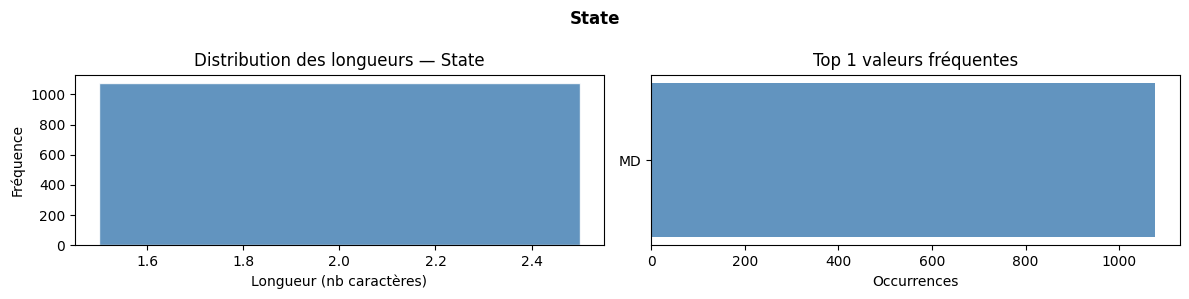


  ────────────────────────────────────────
  Top 10 valeurs les plus fréquentes


,valeur,occurrences,% total,% non-null
0,MD,1076,99.91,100.0


In [69]:
# ── Choisir la colonne à profiler ──────────────────────────────────────
COLUMN = "State"   # ← modifier ici

# ────────────────────────────────────────────────────────────────────────
profile_column(df, COLUMN)